<a href="https://colab.research.google.com/github/swastik2207/EEG_Depression_Detection_Project/blob/main/Kaagle_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub
import os



path = '/content/drive/MyDrive/EEG Data/'

print("Path to dataset files:", path)

Path to dataset files: /content/drive/MyDrive/EEG Data/


In [ ]:
import os

def get_filenames(path):
    filenames = [
        f for f in os.listdir(path)
        if os.path.isfile(os.path.join(path, f))
    ]
    return filenames

filenames = get_filenames(path)

print(filenames)

['eeg_record1.mat', 'eeg_record10.mat', 'eeg_record11.mat', 'eeg_record12.mat', 'eeg_record13.mat', 'eeg_record14.mat', 'eeg_record16.mat', 'eeg_record15.mat', 'eeg_record17.mat', 'eeg_record18.mat', 'eeg_record2.mat', 'eeg_record19.mat', 'eeg_record20.mat', 'eeg_record21.mat', 'eeg_record23.mat', 'eeg_record22.mat', 'eeg_record24.mat', 'eeg_record25.mat', 'eeg_record27.mat', 'eeg_record26.mat', 'eeg_record29.mat', 'eeg_record28.mat', 'eeg_record30.mat', 'eeg_record3.mat', 'eeg_record31.mat', 'eeg_record33.mat', 'eeg_record32.mat', 'eeg_record34.mat', 'eeg_record4.mat', 'eeg_record5.mat', 'eeg_record6.mat', 'eeg_record7.mat', 'eeg_record8.mat', 'eeg_record9.mat']


In [ ]:
!pip install Py-FS
!pip install ReliefF
!pip install scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ReliefF: filename=ReliefF-0.1.2-py3-none-any.whl size=6303 sha256=aca449ac37b6be0f4587f81d10904f4c8edd175606f1e202be6f352b58237342
  Stored in directory: /root/.cache/pip/wheels/18/bb/86/39ea046cb24e9e508e37ddc643a982097c91e5837c93e824f2
Successfully built ReliefF


In [ ]:
##### This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# I found that the eeg_recording28 doesn't have enough data,the date for drowsy is only 76800.

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import scipy.io
import matplotlib.pyplot as plt
import os
from scipy import signal
from scipy.fft import fft, fftshift
from tensorflow.keras import Sequential
import tensorflow as tf

from scipy.signal import butter, lfilter, freqz
# ----- ----- ----- -----
def butter_highpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_highpass_filter(data, cutoff, fs, order=4):
    b, a = butter_highpass(cutoff, fs, order=order)
    x = signal.filtfilt(b, a, data)
    y = signal.filtfilt(b, a, x)
    return y



In [ ]:
#starting from Channel 3,/0,1,2,3
# The introduction of the data set in kaggle doesn't provide enough information.
#And we don't know which data are useful I have to plot all the channels.
#There are 14 channels, but the experimenter modified the headset.
#after removing the DC, the EEG amplitude should be around (-100,100).
#According to the plot, I think ['F7','F3','P7','O1','O2','P8','AF4'] are useful channels.
# fig, ax = plt.subplots(14,1)
# fig.set_figwidth(20)
# fig.set_figheight(50)
#fig.set_size_inches(10,10)
mat = scipy.io.loadmat(os.path.join(path, filenames[0]))
data = mat['o']['data'][0,0]
FS = mat['o']['sampFreq'][0][0][0][0]
channels = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
# for i in range(14):
#     data_ave = data[5000:15000,i+3]-np.mean(data[5000:15000,i+3])
#     ax[i].plot(data_ave)
#     ax[i].set_title(channels[i])
#     ax[i].set_ylim(-100,100)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
#F7,F3,P7,O1,O2,P8,AF4
useful_channels=[3,16]
useful_channels_names=['AF3','AF4']
# fig,ax = plt.subplots(7)
# fig.set_size_inches(20,40)
# j=0
# for i in useful_channels:
#     data_ave = data[5000:15000,i]-np.mean(data[5000:15000,i])
#     ax[j].plot(data_ave)
#     ax[j].set_ylim(-200,200)
#     ax[j].set_title(channels[i-3])
#     j=j+1

In [ ]:
marker=128*60*10
#delete file #28 because it doesnot have enough data
useful_file_index = [3,4,5,6,7,10,11,12,13,14,17,18,19,20,21,24,25,26,27,31,32,33,34]
#useful_file_index = np.arange(1,35)
chan_num=7
trail_names=[]
data_focus={}
data_unfocus={}
data_drowsy={}
focus={}
unfocus={}
drowsy={}
#for i in useful_file_index:
i=1
for index,filename in enumerate(filenames):
    if int(filename.split('d')[1].split('.')[0]) in useful_file_index:
        mat = scipy.io.loadmat(os.path.join(path, filename))
        trail_names.append(filename.split('.')[0])
        data_focus[trail_names[-1]]=mat['o']['data'][0,0][0:marker,useful_channels].copy()
        data_unfocus[trail_names[-1]]=mat['o']['data'][0,0][marker:2*marker,useful_channels].copy()
        data_drowsy[trail_names[-1]]=mat['o']['data'][0,0][2*marker:3*marker,useful_channels].copy()
        focus[trail_names[-1]]=mat['o']['data'][0,0][0:marker,useful_channels].copy()
        unfocus[trail_names[-1]]=mat['o']['data'][0,0][marker:2*marker,useful_channels].copy()
        drowsy[trail_names[-1]]=mat['o']['data'][0,0][2*marker:3*marker,useful_channels].copy()

In [ ]:
data_focus.keys()

dict_keys(['eeg_record10', 'eeg_record11', 'eeg_record12', 'eeg_record13', 'eeg_record14', 'eeg_record17', 'eeg_record18', 'eeg_record19', 'eeg_record20', 'eeg_record21', 'eeg_record24', 'eeg_record25', 'eeg_record27', 'eeg_record26', 'eeg_record3', 'eeg_record31', 'eeg_record33', 'eeg_record32', 'eeg_record34', 'eeg_record4', 'eeg_record5', 'eeg_record6', 'eeg_record7'])

In [ ]:
# High Pass 0.16HZ
row, col = data_focus['eeg_record3'].shape
for name in trail_names:
    for i in range(col):
        data_focus[name][:,i]=butter_highpass_filter(data_focus[name][:,i], 0.16, 128, 4)
        data_unfocus[name][:,i]=butter_highpass_filter(data_unfocus[name][:,i], 0.16, 128, 4)
        data_drowsy[name][:,i]=butter_highpass_filter(data_drowsy[name][:,i], 0.16, 128, 4)
        #print(name,data_drowsy[name][:,i].shape)

In [ ]:
data_focus['eeg_record3']

array([[ -0.19524731, -31.18585926],
       [ -0.19254217, -37.78588503],
       [ -0.18981361, -37.20762557],
       ...,
       [  2.82934613,  66.88767202],
       [  2.8754622 ,  52.8438121 ],
       [  0.87083808,  46.01579802]])

In [ ]:
feature_names = []
freq_range=np.arange(0.5,18.5,0.5)
symb='_'
#useful_channels_names=['AF3','AF4']
for index,channel in enumerate(useful_channels_names):
    for freq in freq_range:
        feature_names.append(channel+symb+str(freq))
feature_names

['AF3_0.5',
 'AF3_1.0',
 'AF3_1.5',
 'AF3_2.0',
 'AF3_2.5',
 'AF3_3.0',
 'AF3_3.5',
 'AF3_4.0',
 'AF3_4.5',
 'AF3_5.0',
 'AF3_5.5',
 'AF3_6.0',
 'AF3_6.5',
 'AF3_7.0',
 'AF3_7.5',
 'AF3_8.0',
 'AF3_8.5',
 'AF3_9.0',
 'AF3_9.5',
 'AF3_10.0',
 'AF3_10.5',
 'AF3_11.0',
 'AF3_11.5',
 'AF3_12.0',
 'AF3_12.5',
 'AF3_13.0',
 'AF3_13.5',
 'AF3_14.0',
 'AF3_14.5',
 'AF3_15.0',
 'AF3_15.5',
 'AF3_16.0',
 'AF3_16.5',
 'AF3_17.0',
 'AF3_17.5',
 'AF3_18.0',
 'AF4_0.5',
 'AF4_1.0',
 'AF4_1.5',
 'AF4_2.0',
 'AF4_2.5',
 'AF4_3.0',
 'AF4_3.5',
 'AF4_4.0',
 'AF4_4.5',
 'AF4_5.0',
 'AF4_5.5',
 'AF4_6.0',
 'AF4_6.5',
 'AF4_7.0',
 'AF4_7.5',
 'AF4_8.0',
 'AF4_8.5',
 'AF4_9.0',
 'AF4_9.5',
 'AF4_10.0',
 'AF4_10.5',
 'AF4_11.0',
 'AF4_11.5',
 'AF4_12.0',
 'AF4_12.5',
 'AF4_13.0',
 'AF4_13.5',
 'AF4_14.0',
 'AF4_14.5',
 'AF4_15.0',
 'AF4_15.5',
 'AF4_16.0',
 'AF4_16.5',
 'AF4_17.0',
 'AF4_17.5',
 'AF4_18.0']

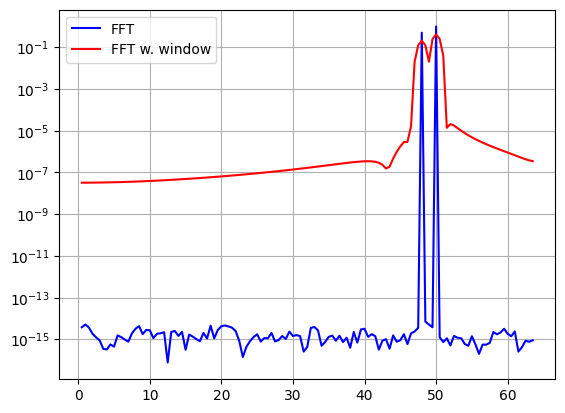

In [ ]:
from scipy.fft import fft, fftfreq
import numpy as np




# Number of sample points
N = 256
# sample spacing
T = 1.0 / 128.0
x = np.linspace(0.0, N*T, N, endpoint=False)
y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
yf = fft(y)

N=256
w = np.blackman(N)
ywf = fft(y*w)
xf = fftfreq(N, T)[:N//2]
import matplotlib.pyplot as plt
plt.semilogy(xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]), '-b')
plt.semilogy(xf[1:N//2], 2.0/N * np.abs(ywf[1:N//2]), '-r')
plt.legend(['FFT', 'FFT w. window'])
plt.grid()
plt.show()

In [ ]:
ywf.shape

data_focus['eeg_record25'][:,1].shape[0]/256

300.0

In [ ]:
# # STFT was then calculated at a time step of 1 s producing a set of time-varying DFT
# # amplitudes X STFT (t,ω) at 1s intervals within each input EEG channel.
# t_win = np.arange(0,128)
# M = 128
# window_blackman=0.42-0.5*np.cos((2*np.pi*t_win)/(M-1))+0.08*np.cos((4*np.pi*t_win)/(M-1))#window_blackman = signal.windows.blackmanharris(128)

# #col is 7
# power_focus = {}
# for name in trail_names:
#     power_focus[name]=np.zeros([col,513,601])

# power_unfocus = {}
# for name in trail_names:
#     power_unfocus[name]=np.zeros([col,513,601])

# power_drowsy = {}
# for name in trail_names:
#     power_drowsy[name]=np.zeros([col,513,601])

# #the output of the stft is 513*601,1 second data will produce 1 column of data,there are 601
# for name in trail_names:
#     for i in range(col):
#         f, t,y1=scipy.signal.stft(data_focus[name][:,i],fs=128, window=window_blackman, nperseg=128,
#                       noverlap=0, nfft=1024, detrend=False,return_onesided=True, boundary='zeros',
#                       padded=True)
#         f, t,y2=scipy.signal.stft(data_unfocus[name][:,i],fs=128, window=window_blackman, nperseg=128,
#                       noverlap=0, nfft=1024, detrend=False,return_onesided=True, boundary='zeros',
#                       padded=True)
#         f, t,y3=scipy.signal.stft(data_drowsy[name][:,i],fs=128, window=window_blackman, nperseg=128,
#                       noverlap=0, nfft=1024, detrend=False,return_onesided=True, boundary='zeros',
#                       padded=True)
#         power_focus[name][i,:,:]=(np.abs(y1))**2
#         power_unfocus[name][i,:,:]=(np.abs(y2))**2
#         power_drowsy[name][i,:,:]=(np.abs(y3))**2

# STFT was then calculated at a time step of 1 s producing a set of time-varying DFT
# amplitudes X STFT (t,ω) at 1s intervals within each input EEG channel.
# t_win = np.arange(0,128)
# M = 128
# window_blackman=0.42-0.5*np.cos((2*np.pi*t_win)/(M-1))+0.08*np.cos((4*np.pi*t_win)/(M-1))#window_blackman = signal.windows.blackmanharris(128)

# Number of sample points
N = 256
# sample spacing
T = 1.0 / 128.0

w = np.blackman(N)

#col is 2
power_focus = {}
for name in trail_names:
    power_focus[name]=np.zeros([col,36,300])

power_unfocus = {}
for name in trail_names:
    power_unfocus[name]=np.zeros([col,36,300])

power_drowsy = {}
for name in trail_names:
    power_drowsy[name]=np.zeros([col,36,300])

#the output of the stft is 513*601,1 second data will produce 1 column of data,there are 601
for name in trail_names:
    for i in range(col):
        for j in range(300):
            y1=fft(data_focus[name][:,i][j*256:(j+1)*256]*w)
            y2=fft(data_unfocus[name][:,i][j*256:(j+1)*256]*w)
            y3=fft(data_drowsy[name][:,i][j*256:(j+1)*256]*w)
            power_focus[name][i,:,j]=2.0/N * np.abs(y1[0:36])
            power_unfocus[name][i,:,j]=2.0/N * np.abs(y2[0:36])
            power_drowsy[name][i,:,j]=2.0/N * np.abs(y3[0:36])



In [ ]:
power_focus['eeg_record33'][0,:,:]

array([[0.58595255, 0.24387699, 2.12683848, ..., 0.53148684, 0.2593596 ,
        1.19236682],
       [1.36163388, 2.15539968, 2.38024284, ..., 1.14912875, 0.79605628,
        1.02907424],
       [0.96667016, 1.1848778 , 1.49716379, ..., 1.04367257, 0.78057248,
        0.34692312],
       ...,
       [0.23015927, 0.16206308, 0.28624466, ..., 0.26002184, 0.18017338,
        0.05897799],
       [0.06770279, 0.11273217, 0.09556083, ..., 0.31454114, 0.18783779,
        0.10684232],
       [0.13744115, 0.0705755 , 0.07933554, ..., 0.30145706, 0.07320653,
        0.08346765]])

In [ ]:
# # avarage over 15 seconds running window.

# power_focus_ave = {}
# for name in trail_names:
#     power_focus_ave[name]=np.zeros([2,36,585])

# power_unfocus_ave = {}
# for name in trail_names:
#     power_unfocus_ave[name]=np.zeros([2,36,585])

# power_drowsy_ave = {}
# for name in trail_names:
#     power_drowsy_ave[name]=np.zeros([2,36,585])

# for name in trail_names:
#     for chn in range(col):
#         j=0
#         for k in range(0,585):
#             power_focus_ave[name][chn,:,j]=np.average(power_focus_bin[name][chn,:,k:k+15],axis=1)
#             power_unfocus_ave[name][chn,:,j]=np.average(power_unfocus_bin[name][chn,:,k:k+15],axis=1)
#             power_drowsy_ave[name][chn,:,j]=np.average(power_drowsy_bin[name][chn,:,k:k+15],axis=1)
#             #print(np.average(power_drowsy_bin[name][chn,:,k:k+15],axis=1).shape)
#             j=j+1

# avarage over 15 seconds running window.

power_focus_ave = {}
for name in trail_names:
    power_focus_ave[name]=np.zeros([2,36,292])

power_unfocus_ave = {}
for name in trail_names:
    power_unfocus_ave[name]=np.zeros([2,36,292])

power_drowsy_ave = {}
for name in trail_names:
    power_drowsy_ave[name]=np.zeros([2,36,292])

for name in trail_names:
    for chn in range(col):
        j=0
        for k in range(0,292):
            power_focus_ave[name][chn,:,j]=np.average(power_focus[name][chn,:,k:k+8],axis=1)
            power_unfocus_ave[name][chn,:,j]=np.average(power_unfocus[name][chn,:,k:k+8],axis=1)
            power_drowsy_ave[name][chn,:,j]=np.average(power_drowsy[name][chn,:,k:k+8],axis=1)
            #print(np.average(power_drowsy_bin[name][chn,:,k:k+15],axis=1).shape)
            j=j+1

In [ ]:
# Turn the data into a vector
#[72,300]

svm_focus = {}
for name in trail_names:
    svm_focus[name]=np.zeros([72,300])

svm_unfocus = {}
for name in trail_names:
    svm_unfocus[name]=np.zeros([72,300])

svm_drowsy = {}
for name in trail_names:
    svm_drowsy[name]=np.zeros([72,300])

for name in trail_names:
    for j in range(300):
        svm_focus[name][:,j]=power_focus[name][:,:,j].reshape(1,-1)
        svm_unfocus[name][:,j]=power_unfocus[name][:,:,j].reshape(1,-1)
        svm_drowsy[name][:,j]=power_drowsy[name][:,:,j].reshape(1,-1)
    svm_focus[name]=10*np.log(svm_focus[name])
    svm_unfocus[name]=10*np.log(svm_unfocus[name])
    svm_drowsy[name]=10*np.log(svm_drowsy[name])
# now, we get the svm vector 252*585 252 rows


In [ ]:
#--------0
label_focus = [0]*300
#--------1
label_unfocus = [1]*300
#--------2
label_drowsy = [2]*300

#subject is the variable for all participants

subj1_files={'eeg_record3','eeg_record4','eeg_record5','eeg_record6','eeg_record7'}
subj2_files={'eeg_record10','eeg_record11','eeg_record12','eeg_record13','eeg_record14'}
subj3_files={'eeg_record17','eeg_record18','eeg_record19','eeg_record20','eeg_record21'}
subj4_files={'eeg_record24','eeg_record25','eeg_record26','eeg_record27'}
subj5_files={'eeg_record31','eeg_record32','eeg_record33','eeg_record34'}


In [ ]:
# I will try to use the data from all participants to train the model
target=[]
subj=np.array([]).reshape(72,0).copy()
for name in trail_names:
    subj=np.concatenate((subj,svm_focus[name]), axis=1)
    subj=np.concatenate((subj,svm_unfocus[name]), axis=1)
    subj=np.concatenate((subj,svm_drowsy[name]), axis=1)
    target = target+label_focus+label_unfocus+label_drowsy
subj=subj.T
target = np.array(target)

In [ ]:
# This part I only train the data for subject1
target1=[]
subj1=np.array([]).reshape(72,0).copy()
for name in subj1_files:
    subj1=np.concatenate((subj1,svm_focus[name]), axis=1)
    subj1=np.concatenate((subj1,svm_unfocus[name]), axis=1)
    subj1=np.concatenate((subj1,svm_drowsy[name]), axis=1)
    target1 = target1+label_focus+label_unfocus+label_drowsy
subj1=subj1.T
target1 = np.array(target1)

In [ ]:
target2=[]
subj2=np.array([]).reshape(72,0).copy()
for name in subj2_files:
    subj2=np.concatenate((subj2,svm_focus[name]), axis=1)
    subj2=np.concatenate((subj2,svm_unfocus[name]), axis=1)
    subj2=np.concatenate((subj2,svm_drowsy[name]), axis=1)
    target2 = target2+label_focus+label_unfocus+label_drowsy
subj2=subj2.T
target2 = np.array(target2)

In [ ]:
target3=[]
subj3=np.array([]).reshape(72,0).copy()
for name in subj3_files:
    subj3=np.concatenate((subj3,svm_focus[name]), axis=1)
    subj3=np.concatenate((subj3,svm_unfocus[name]), axis=1)
    subj3=np.concatenate((subj3,svm_drowsy[name]), axis=1)
    target3 = target3+label_focus+label_unfocus+label_drowsy
subj3=subj3.T
target3 = np.array(target3)

In [ ]:
target4=[]
subj4=np.array([]).reshape(72,0).copy()
for name in subj4_files:
    subj4=np.concatenate((subj4,svm_focus[name]), axis=1)
    subj4=np.concatenate((subj4,svm_unfocus[name]), axis=1)
    subj4=np.concatenate((subj4,svm_drowsy[name]), axis=1)
    target4 = target4+label_focus+label_unfocus+label_drowsy
subj4=subj4.T
target4 = np.array(target4)

In [ ]:
target5=[]
subj5=np.array([]).reshape(72,0).copy()
for name in subj5_files:
    subj5=np.concatenate((subj5,svm_focus[name]), axis=1)
    subj5=np.concatenate((subj5,svm_unfocus[name]), axis=1)
    subj5=np.concatenate((subj5,svm_drowsy[name]), axis=1)
    target5 = target5+label_focus+label_unfocus+label_drowsy
subj5=subj5.T
target5 = np.array(target5)

In [ ]:
print('length of the target:',len(target))
print('the shape of the data from the subject1:', subj.shape)

length of the target: 20700
the shape of the data from the subject1: (20700, 72)


In [ ]:
n_past=8
subj_new=[]
for i in range(n_past ,len(subj)):
    subj_new.append(subj[i-n_past:i,0:72])
subj_new=np.array(subj_new)

In [ ]:
target_new=target[n_past:]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.svm import SVC

arr = np.arange(20692)
np.random.shuffle(arr)
data_train, data_test,data_train_target, data_test_target = subj_new[arr[:20000]],subj_new[arr[20000:]],target_new[arr[:20000]],target_new[arr[20000:]]

X_train_scaled = scaler.transform(data_train)
X_test_scaled = scaler.transform(data_test)

ValueError: Found array with dim 3. StandardScaler expected <= 2.

In [ ]:

from sklearn.preprocessing import OneHotEncoder
en=OneHotEncoder()
data_train_target1=en.fit_transform(data_train_target.reshape(-1,1))
data_test_target1=en.fit_transform(data_test_target.reshape(-1,1))

In [ ]:
data_train_target1 = data_train_target1.toarray()
data_test_target1 = data_test_target1.toarray()


In [ ]:
data_train.shape

(20000, 8, 72)


[Phase 1] Training Deep Feature Extractor...
Epoch 1/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4749 - loss: 1.3689
Epoch 1: val_accuracy improved from None to 0.63295, saving model to feature_extractor_weights.keras

Epoch 1: finished saving model to feature_extractor_weights.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.5420 - loss: 1.2387 - val_accuracy: 0.6329 - val_loss: 1.2232
Epoch 2/30
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6966 - loss: 0.9216
Epoch 2: val_accuracy did not improve from 0.63295
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step - accuracy: 0.7283 - loss: 0.8409 - val_accuracy: 0.6040 - val_loss: 1.1022
Epoch 3/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8489 - loss: 0.5270
Epoch 3: val_accuracy did not improve from 0.63295
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8656 - loss: 0.4708 - val_accuracy: 0.5708 - val_loss: 1.6383
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0

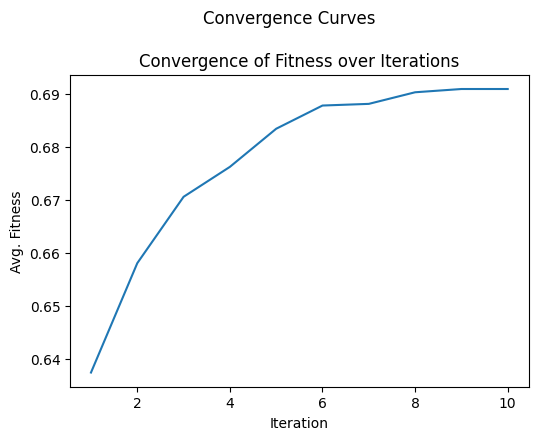

GA reduced features from 256 to 76

[Phase 3] Training Final SVM...

--- Classification Report (Deep Features + GA + SVM) ---
              precision    recall  f1-score   support

       Focus       0.97      0.99      0.98       231
     Unfocus       0.99      0.97      0.98       234
      Drowsy       0.98      0.98      0.98       227

    accuracy                           0.98       692
   macro avg       0.98      0.98      0.98       692
weighted avg       0.98      0.98      0.98       692



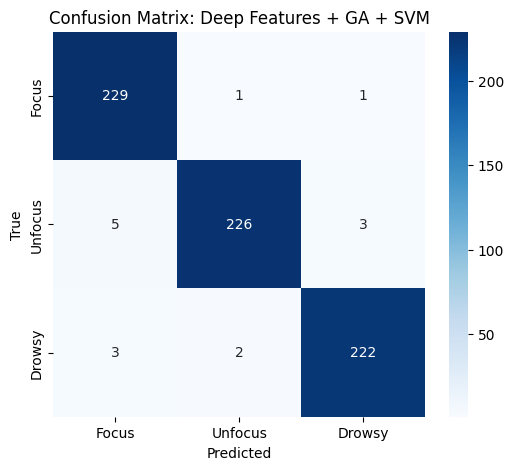

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# --- Py_FS Import for Genetic Algorithm ---
from Py_FS.wrapper.nature_inspired import GA

# --- Framework Imports ---
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, PReLU, MaxPooling2D, Flatten, Reshape,
    Bidirectional, LSTM, GRU, Dense, Dropout,
    GlobalAveragePooling2D, Multiply, Input,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Add, Concatenate, Lambda

# ---------------------------------------------------------
# 1. Setup & Data Loading
# Using existing data_train, data_test, data_train_target1, data_test_target1
# ---------------------------------------------------------
X_train, X_test = data_train, data_test
y_train, y_test = data_train_target1, data_test_target1

input_shape = X_train.shape[1:]

# ---------------------------------------------------------
# 2. Custom Channel Attention Layer (defined but not used in the provided model structure)
# ---------------------------------------------------------
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        self.shared_layer_one = Dense(self.filters // self.ratio,
                                     activation='relu', kernel_initializer='he_normal',
                                     use_bias=True, bias_initializer='zeros')
        self.shared_layer_two = Dense(self.filters,
                                     kernel_initializer='he_normal',
                                     use_bias=True, bias_initializer='zeros')
        super(ChannelAttention, self).build(input_shape)

    def call(self, inputs):
        avg_pool = GlobalAveragePooling2D()(inputs)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)
        scale = tf.keras.activations.sigmoid(avg_pool)
        scale = Reshape((1, 1, self.filters))(scale)
        return Multiply()([inputs, scale])

    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        config.update({'filters': self.filters, 'ratio': self.ratio})
        return config

# ---------------------------------------------------------
# 3. Build Deep Feature Extractor
# ---------------------------------------------------------

def build_feature_extractor(input_shape):
    reg = l2(0.001)
    inputs = Input(shape=input_shape)

    # Reshape input for Conv2D (samples, timesteps, 1, features)
    x = Reshape((input_shape[0], 1, input_shape[1]))(inputs)

    # ================================
    # ┅ CNN BLOCK
    # ================================
    for _ in range(4):
        x = Conv2D(128, (3, 1), padding='same')(x) # Added padding to maintain dimensions
        x = BatchNormalization()(x)
        x = PReLU()(x)

    x = MaxPooling2D((2, 1))(x)
    x = Dropout(0.3)(x)

    cnn_out = x  # save CNN output

    # ================================
    # ┅ SPATIAL FEATURES (CNN)
    # ================================
    spatial = GlobalAveragePooling2D()(cnn_out)
    spatial = Dense(256)(spatial)
    spatial = BatchNormalization()(spatial)
    spatial = PReLU()(spatial)

    # ================================
    # ┅ TEMPORAL FEATURES (RNN)
    # ================================
    rnn = Flatten()(cnn_out)
    # Reshape for LSTM: (batch, timesteps, features)
    # cnn_out shape: (batch, new_timesteps, 1, 128) after pooling and convs
    # Flatten leads to (batch, new_timesteps * 1 * 128)
    # We need to reshape to (batch, new_timesteps, 128)
    # Need to calculate `new_timesteps` after CNN and pooling operations
    new_timesteps = cnn_out.shape[1] # This is dynamic based on input_shape[0] and conv/pool layers
    rnn = Reshape((new_timesteps, 128))(rnn) # Assuming 128 filters from Conv2D

    rnn = Bidirectional(LSTM(256, return_sequences=True, dropout=0.3))(rnn)
    rnn = Bidirectional(GRU(128, return_sequences=False, dropout=0.3))(rnn)

    temporal = Dense(256)(rnn)
    temporal = BatchNormalization()(temporal)
    temporal = PReLU()(temporal)

    # ================================
    #  MULTI-HEAD GATED FUSION
    # ================================
    num_heads = 4

    fusion_input = Concatenate()([spatial, temporal])  # (512)

    head_outputs = []

    for i in range(num_heads):
        gate = Dense(256, activation='sigmoid', name=f'gate_head_{i}')(fusion_input)

        inv_gate = Lambda(lambda g: 1.0 - g)(gate)

        spatial_weighted = Multiply()([spatial, gate])
        temporal_weighted = Multiply()([temporal, inv_gate])

        head_fusion = Add()([spatial_weighted, temporal_weighted])

        head_outputs.append(head_fusion)

    # Combine all heads
    fusion = Concatenate()(head_outputs)   # (256 * num_heads)

    # Project back to 256
    fusion = Dense(256)(fusion)
    fusion = BatchNormalization()(fusion)
    fusion = PReLU()(fusion)

    # ================================
    # ┅ FINAL FEATURE LAYERS
    # ================================
    x = Dense(128, kernel_regularizer=reg)(fusion)
    x = BatchNormalization()(x)
    x = PReLU()(x)
    x = Dropout(0.4)(x)

    features = Dense(256, kernel_regularizer=reg, name='svm_features')(x)
    features = BatchNormalization()(features)
    features = PReLU()(features)

    outputs = Dense(3, activation='softmax', name='temp_softmax')(features)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ---------------------------------------------------------
# 4. Phase 1: Train Deep Network
# ---------------------------------------------------------
print("\n[Phase 1] Training Deep Feature Extractor...")
model = build_feature_extractor(input_shape)

y_train_integers = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_integers), y=y_train_integers)
class_weights_dict = dict(zip(np.unique(y_train_integers), class_weights))

checkpoint_path = 'feature_extractor_weights.keras'
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Adjust epochs for demonstration if needed, original was 30
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32,
          callbacks=callbacks, class_weight=class_weights_dict, verbose=1)

# ---------------------------------------------------------
# 5. Phase 2: Feature Extraction & Genetic Algorithm
# ---------------------------------------------------------
print("\n[Phase 2] Extracting and Selecting Features via GA...")

# Load weights and isolate feature layer
model.load_weights(checkpoint_path)
extractor_model = Model(inputs=model.input, outputs=model.get_layer('svm_features').output)

X_train_raw = extractor_model.predict(X_train)
X_test_raw = extractor_model.predict(X_test)

# Scale features for GA and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)
y_train_svm = np.argmax(y_train, axis=1)
y_test_svm = np.argmax(y_test, axis=1)

# Run Genetic Algorithm Selection
# Note: num_agents and max_iter can be increased for better results
# Using a smaller number of agents and iterations for quicker execution
solution = GA(num_agents=10, max_iter=10, train_data=X_train_scaled, train_label=y_train_svm) # Reduced for faster execution
selected_indices = solution.best_agent

# Apply selection mask
X_train_ga = X_train_scaled[:, selected_indices == 1]
X_test_ga = X_test_scaled[:, selected_indices == 1]

print(f"GA reduced features from 256 to {X_train_ga.shape[1]}")

# ---------------------------------------------------------
# 6. Phase 3: Final SVM Classification
# ---------------------------------------------------------
print("\n[Phase 3] Training Final SVM...")
final_svm = SVC(kernel='rbf', C=1.0, class_weight='balanced')
final_svm.fit(X_train_ga, y_train_svm)

y_pred = final_svm.predict(X_test_ga)

# ---------------------------------------------------------
# 7. Evaluation
# ---------------------------------------------------------
print("\n--- Classification Report (Deep Features + GA + SVM) ---")
print(classification_report(y_test_svm, y_pred, target_names=['Focus', 'Unfocus', 'Drowsy']))

cm = confusion_matrix(y_test_svm, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Focus', 'Unfocus', 'Drowsy'], yticklabels=['Focus', 'Unfocus', 'Drowsy'])
plt.title('Confusion Matrix: Deep Features + GA + SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
nn.fit(data_train,data_train_target1,epochs=20)

Epoch 1/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0741
Epoch 2/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0745
Epoch 3/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0727
Epoch 4/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0645
Epoch 5/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0631
Epoch 6/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0727
Epoch 7/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0695
Epoch 8/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0620
Epoch 9/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0589
Epoch 10/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0602
Epoch 11/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0636
Epoch 12/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0574
Epoch 13/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0565
Epoch 14/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0594
Epoch 15/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
pred=nn.predict(data_train)
pre=np.argmax(pred,axis=1)

518/518 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


In [ ]:
np.sum(pre==data_train_target)/len(pre)

np.float64(0.9842928774240319)

In [ ]:
pred=nn.predict(data_test)
pre=np.argmax(pred,axis=1)
np.sum(pre==data_test_target)/len(pre)

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


np.float64(0.9490215027784489)